## Models with companion

| model name  | Planet mass | Planet position | |
| -------- | ------- | ------- | ------- |
| fargo_fiducial_super_light_companion | 0.56 Jupiter masses  | 2.28$r_0$ = 130 au | |
| fargo_fiducial_light_companion| 1.25 Jupiter masses|2.28$r_0$ = 130 au | |
| fargo_fiducial_companion  | 2.5 Jupiter masses   | 2.28$r_0$ = 130 au | |
| fargo_fiducial_heavy_companion | 5 Jupiter masses|2.28$r_0$ = 130 au | |
| -------- | ------- | ------- | ------- |
|fargo_fiducial_close_companion| 2.5 Jupiter masses| 2.0$r_0$ = 114 au | |
|fargo_fiducial_close_light_companion| 1.25 Jupiter masses| 2.0$r_0$ = 114 au | |
|fargo_fiducial_close_super_light_companion | 0.56 Jupiter masses  | 2.0$r_0$ = 114 au |
| -------- | ------- | ------- | ------- |
|fargo_fiducial_closer_companion | 2.5 Jupiter masses  | 1.7$r_0$ = 97 au |  |
|fargo_fiducial_closer_light_companion | 1.25 Jupiter masses  | 1.7$r_0$ = 97 au |
|fargo_fiducial_closer_super_light_companion | 0.56 Jupiter masses  |  1.7$r_0$ = 97 au |
| -------- | ------- | ------- | ------- |
| fargo_fiducial_companion_with_feelings  | 2.5 Jupiter masses   | 2.28$r_0$ = 130 au | FEELS OTHERS: YES |


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
path_start = f"/pfs/10/work/hd_cu284-work/fargo3d/outputs/"
path_endings=["fargo_fiducial_companion","fargo_fiducial_super_light_companion","fargo_fiducial_light_companion", "fargo_fiducial_heavy_companion",
              "fargo_fiducial_close_companion","fargo_fiducial_close_light_companion", "fargo_fiducial_companion_with_feelings",
              "fargo_fiducial_close_super_light_companion", "fargo_fiducial_closer_light_companion", "fargo_fiducial_closer_super_light_companion","fargo_fiducial_closer_companion"]
              
              #"fargo_fiducial_2gen", "fargo_high_mass_2gen",  "fargo_low_mass_2gen", "fargo_high_visc_2gen", "fargo_low_visc_2gen",
              #"fargo_sigslop_0_2gen","fargo_sigslop_0.5_2gen", "fargo_sigslop_-2_2gen", "fargo_sigslop_1.5_2gen",  

paths = []
for i in range(len(path_endings)):
    paths.append(path_start+path_endings[i])

path = paths[-1]

In [3]:


frames = [0,1,10,100]

rho_cube=[] # first index: which alpha, second index: which snapshot.
for path in paths:
    rho_cube.append([])
    for i in frames:
        rho = np.fromfile(f"{path}/gasdens{i}.dat").reshape(300, 384)
        rho_cube[-1].append(rho)

rho_cube=np.array(rho_cube)

### calculate disk mass at dens=1
au  = 1.49598e13     # Astronomical Unit       [cm]
ms  = 1.98892e33     # Solar mass              [g]
mstar    = 1.08*ms #ms
r0       = 57*au    # The radius corresponding to '1' in dimensionless units

r_min = 0.3
r_max = 7

sigma_0 = 6.3661977237e-4 * mstar / (r0*r0)

rho_cube = rho_cube*mstar/r0**2

In [ ]:
%matplotlib inline
r_min = 0.3
r_max = 7

for i in range(len(paths[:])):
    plt.figure(figsize=(7*len(frames),5))
    path = paths[i]
    for it,frame in enumerate(frames[:]):
        if frame ==0:
            continue
        plt.subplot(1,len(frames),it+1)
        plt.imshow(np.log10(rho_cube[i][it]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)], clim = (1,-3))
        plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, {path[43:-5]}, {(frame)*10} orbits")
        plt.ylabel("$log10(r/r_0)$")
        plt.xlabel("$\\varphi$")
        plt.colorbar()


In [5]:
Nr = 300
Nphi = 384

r_list = np.fromfile(f"{path}/domain_y.dat", sep="\n")[3:-4]
phi = np.linspace(0, 2*np.pi, Nphi)

R, PHI = np.meshgrid(r_list, phi, indexing='ij')

In [9]:
"""
rho_mean = np.mean(rho_cube, axis=2)

plt.plot(r_list,rho_mean[frames[-1]]/rho_mean[0], label=f"{path[43:-5]}")

r1 = 130/57
plt.plot([1,1],[1e-3,1e1], label="planet 1")
plt.plot([r1,r1],[1e-3,1e1], label="planet 2")


r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

gap = 69/r_p
gap_width = 59/2/r_p

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma/\\Sigma_0$")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend()
"""

'\nrho_mean = np.mean(rho_cube, axis=2)\n\nplt.plot(r_list,rho_mean[frames[-1]]/rho_mean[0], label=f"{path[43:-5]}")\n\nr1 = 130/57\nplt.plot([1,1],[1e-3,1e1], label="planet 1")\nplt.plot([r1,r1],[1e-3,1e1], label="planet 2")\n\n\nr_p = 57.3\nr_p_upper = r_p+8.3\nr_p_lower = r_p-3.3\nrings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p\nrings_lower = np.array([316, 164, 97, 39])/r_p_lower\nrings_upper = np.array([316, 164, 97, 39])/r_p_upper\n\ngap = 69/r_p\ngap_width = 59/2/r_p\n\nfirst=True\nfor it,r in enumerate(rings_from_capelleveen):\n    if first:\n        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")\n        first=False\n        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")\n    else:\n        plt.plot([r,r,],[1e-3,1e1], color="gray", linestyle="dashed")\n        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e1, alpha=0.2, color="gray")\n\nplt.xlabel("$

In [10]:
"""
from scipy.signal import argrelextrema

# for local maxima

press = rho_mean[frames[-1]]*np.power(r_list,-7/4)
local_max = argrelextrema(press, np.greater)
plt.plot(r_list,press, label=f"{path[43:-5]}")

## dots are local extrema
plt.scatter(r_list[local_max], press[local_max])

## Capelleveen rings and dust ring

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_dust_traps.png")
"""

'\nfrom scipy.signal import argrelextrema\n\n# for local maxima\n\npress = rho_mean[frames[-1]]*np.power(r_list,-7/4)\nlocal_max = argrelextrema(press, np.greater)\nplt.plot(r_list,press, label=f"{path[43:-5]}")\n\n## dots are local extrema\nplt.scatter(r_list[local_max], press[local_max])\n\n## Capelleveen rings and dust ring\n\nfirst=True\nr_p = 57.3\nr_p_upper = r_p+8.3\nr_p_lower = r_p-3.3\nrings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p\nrings_lower = np.array([316, 164, 97, 39])/r_p_lower\nrings_upper = np.array([316, 164, 97, 39])/r_p_upper\n\ndust_ring = 144.4/r_p\ndust_ring_upper = 144.4/r_p_upper\ndust_ring_lower = 144.4/r_p_lower\n\nplt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")\nplt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")\n\nfirst=True\nfor it,r in enumerate(rings_from_capelleveen):\n    if first:\n        plt.plot([r,r,],[1e-3,1e2], color="gray", lin

# Different masses at $2.28r_0$

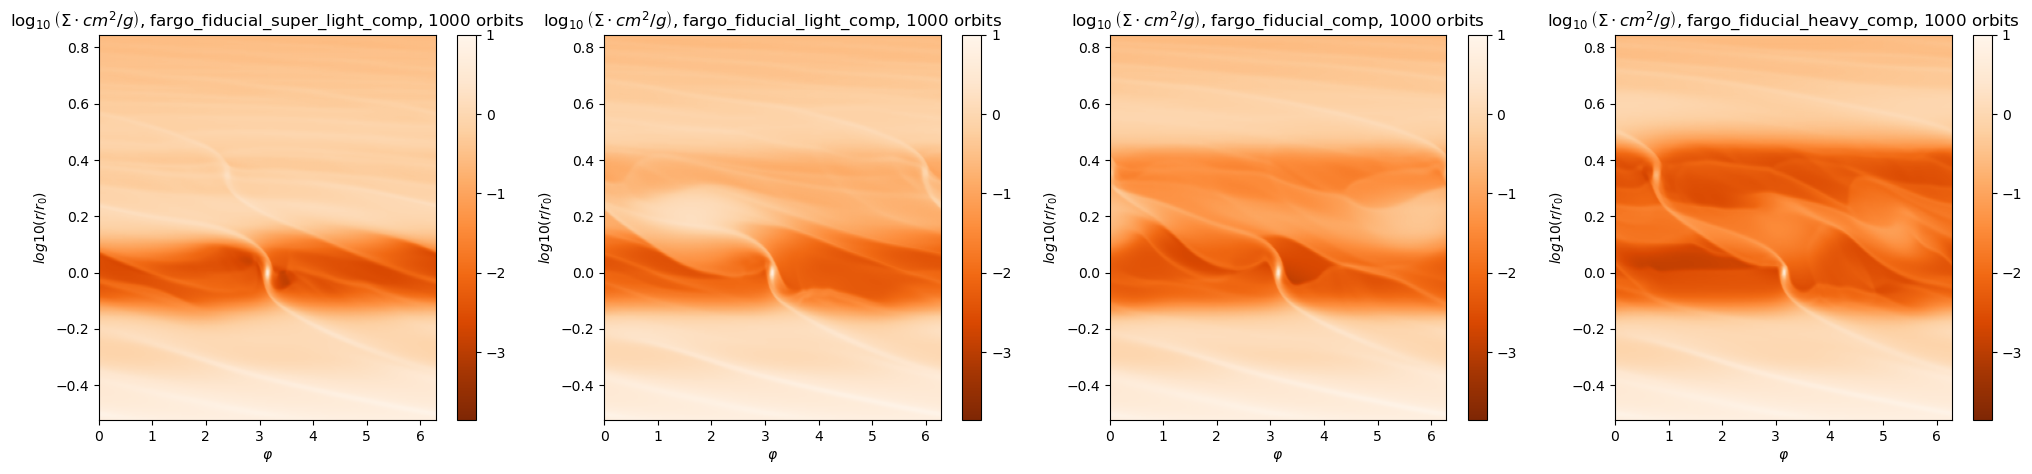

In [19]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_comp_mass=[1,2,0,3]

frame = frames[-1]
plt.figure(figsize=(25,5))

for it,i in enumerate(index_for_comp_mass):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

plt.savefig("radmc3d_sims/img/fargo_companion.PNG")

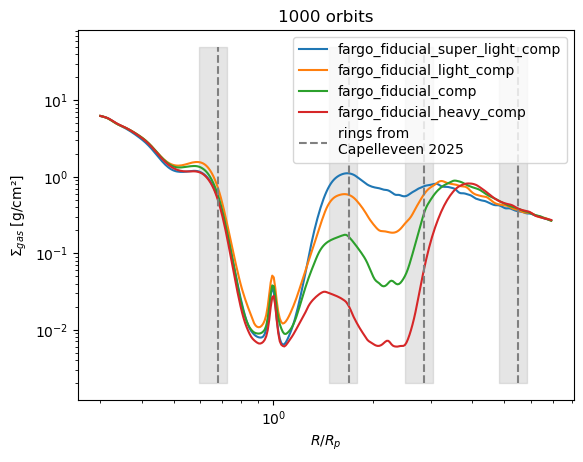

In [20]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_comp_mass:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper



first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
        

#plt.plot([gap,gap,],[1e-3,1e1], color="gray",label="gap from \nCapelleveen 2025")
#plt.fill_between([gap-gap_width,gap+gap_width], 1e-3,1e1, alpha=0.2)

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_masses_densities.png")


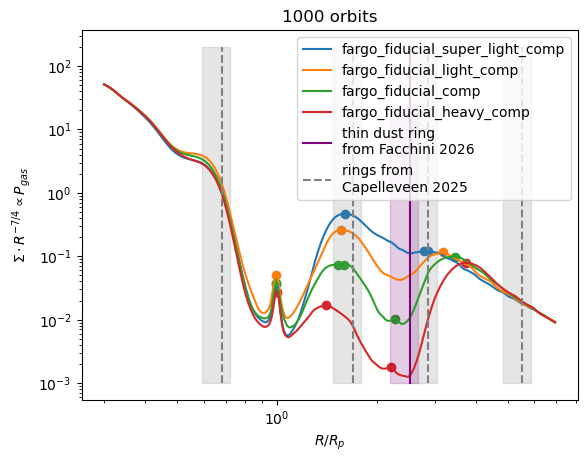

In [21]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_comp_mass:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,2e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,22, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,2e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,2e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_masses_dust_traps.png")

# Different masses at $2r_0$

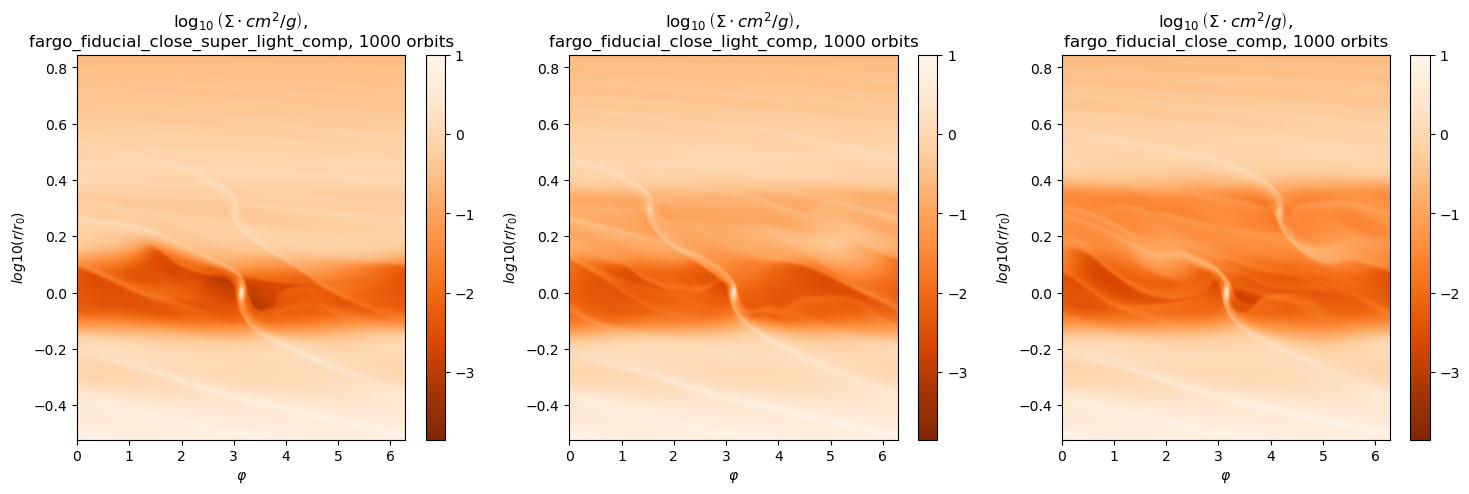

In [6]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_comp_close=[7,5,4]


plt.figure(figsize=(18,5))

for it,i in enumerate(index_for_comp_close[:]):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, \n{path[43:-5]}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

plt.savefig("radmc3d_sims/img/fargo_close_companion.PNG")

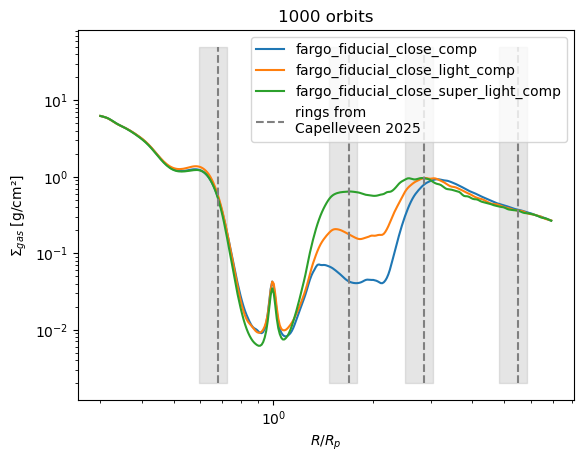

In [23]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_comp_close:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper



first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
        

#plt.plot([gap,gap,],[1e-3,1e1], color="gray",label="gap from \nCapelleveen 2025")
#plt.fill_between([gap-gap_width,gap+gap_width], 1e-3,1e1, alpha=0.2)

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_close_densities.png")


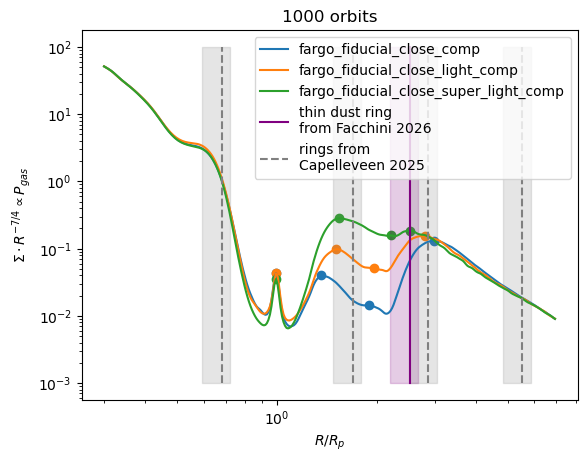

In [42]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_comp_close:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_close_dust_traps.png")

### Scattering surface?????

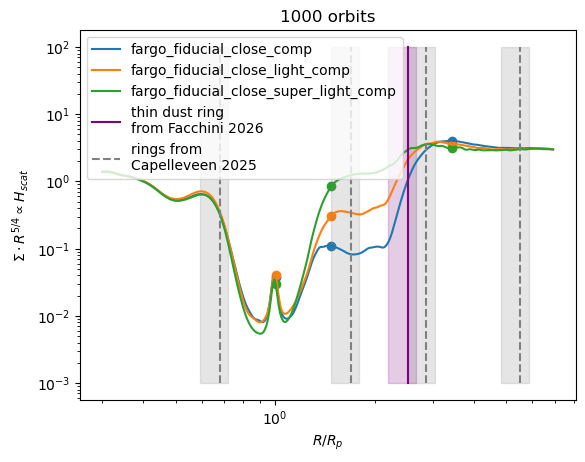

In [41]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_comp_close:
    path = paths[i]
    hscat = rho_mean[i][-1]*np.power(r_list,5/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,hscat, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], hscat[local_max])



first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{5/4} \\propto H_{scat} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper left")
plt.savefig("radmc3d_sims/img/companion_close_dust_traps.png")

# Feelings/ No feelings

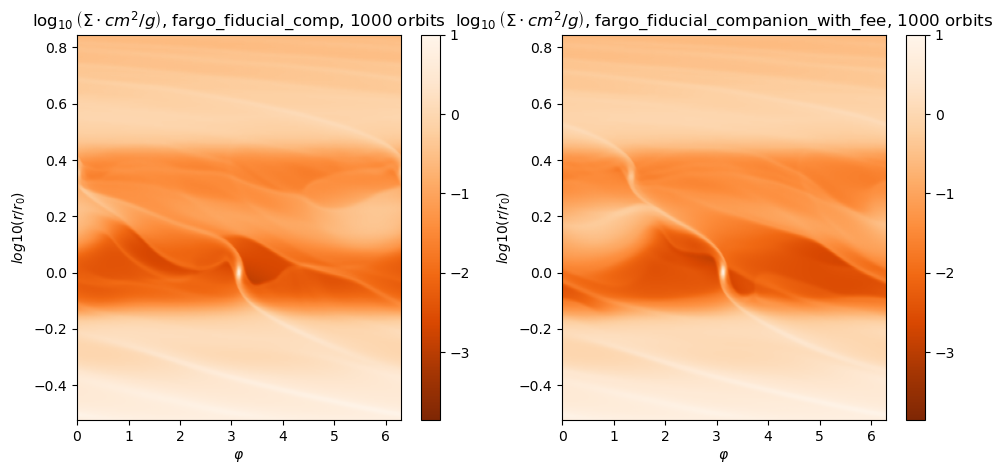

In [26]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_feelings=[0,6]


plt.figure(figsize=(24,5))

for it,i in enumerate(index_for_feelings):
    path = paths[i]
    
        
    plt.subplot(1,4,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, {path[43:-5]}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()


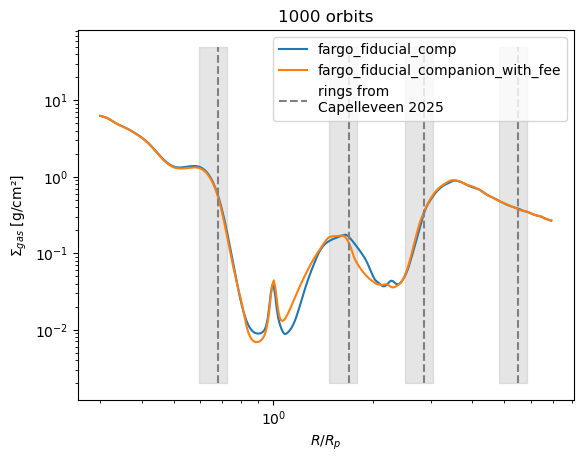

In [27]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_feelings:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper



first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
        

#plt.plot([gap,gap,],[1e-3,1e1], color="gray",label="gap from \nCapelleveen 2025")
#plt.fill_between([gap-gap_width,gap+gap_width], 1e-3,1e1, alpha=0.2)

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_feelings_densities.png")


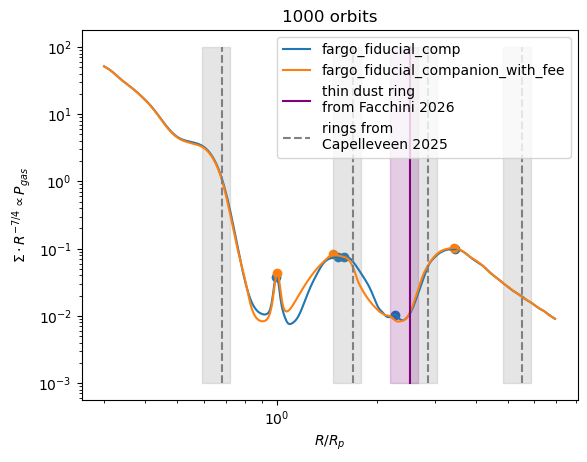

In [40]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_feelings:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_feelings_dust_traps.png")

# Different masses at $1.7 r_0$

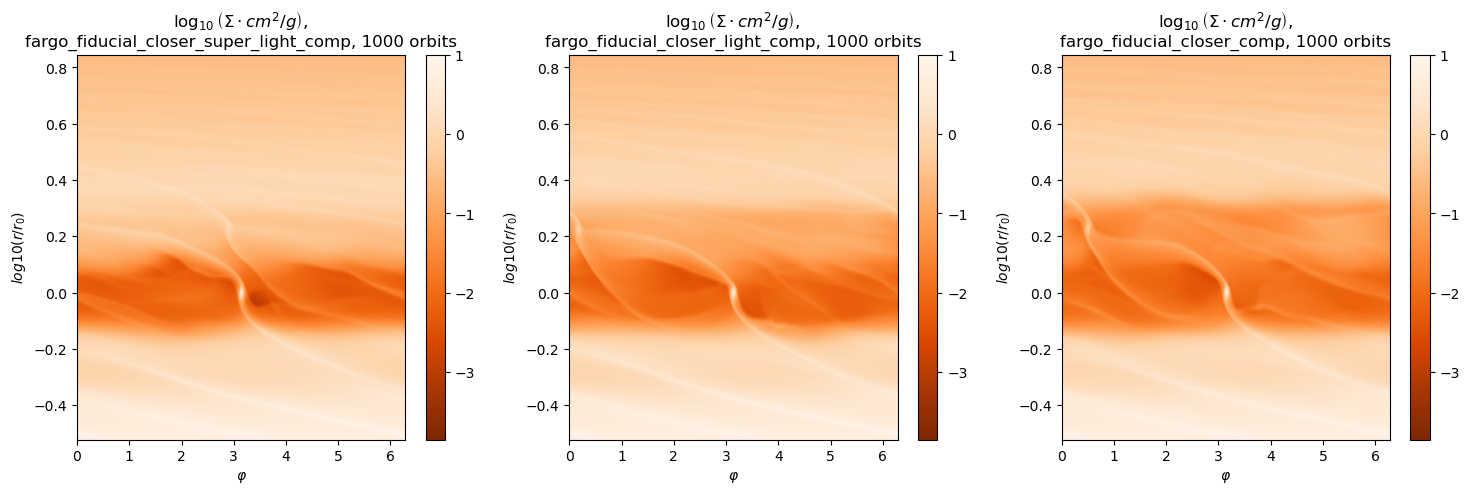

In [29]:
%matplotlib inline
r_min = 0.3
r_max = 7
index_for_closer=[9,8,10]


plt.figure(figsize=(18,5))

for it,i in enumerate(index_for_closer):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, \n{path[43:-5]}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

plt.savefig("radmc3d_sims/img/fargo_closer_companion.PNG")

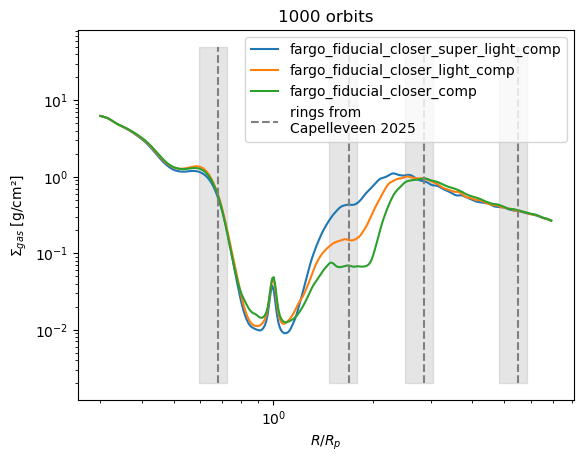

In [38]:
rho_mean = np.mean(rho_cube, axis=3)
for i in index_for_closer:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper



first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
        

#plt.plot([gap,gap,],[1e-3,1e1], color="gray",label="gap from \nCapelleveen 2025")
#plt.fill_between([gap-gap_width,gap+gap_width], 1e-3,1e1, alpha=0.2)

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_closer_densities.png")


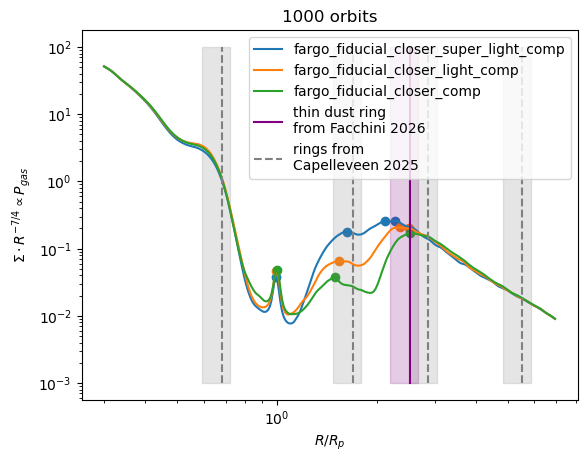

In [39]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_for_closer:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_closer_dust_traps.png")

# Best (for now)

| model name  | Planet mass | Planet position | |
| -------- | ------- | ------- | ------- |
|fargo_fiducial_close_super_light_companion | 0.56 Jupiter masses  | 2.0$r_0$ = 114 au |
|fargo_fiducial_closer_light_companion | 1.25 Jupiter masses  | 1.7$r_0$ = 97 au |

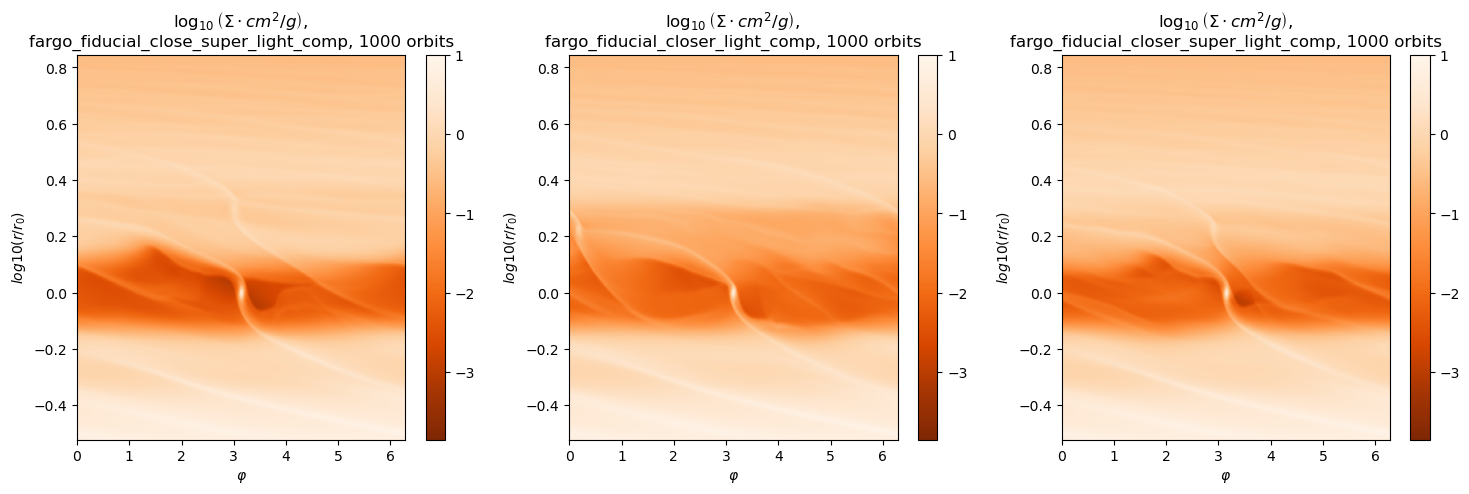

In [35]:
index_best_candidates = [7,8,9]
plt.figure(figsize=(18,5))

for it,i in enumerate(index_best_candidates):
    path = paths[i]
    
        
    plt.subplot(1,3,it+1)
    plt.imshow(np.log10(rho_cube[i][-1]), origin='lower', cmap=cm.Oranges_r, aspect='auto',extent=[0,2*np.pi,np.log10(r_min), np.log10(r_max)],clim = (1,-3.5))
    plt.title(f"$\\log_{{10}} \\left(\\Sigma \\cdot cm^2/g\\right)$, \n{path[43:-5]}, {(frame)*10} orbits")
    plt.ylabel("$log10(r/r_0)$")
    plt.xlabel("$\\varphi$")
    plt.colorbar()

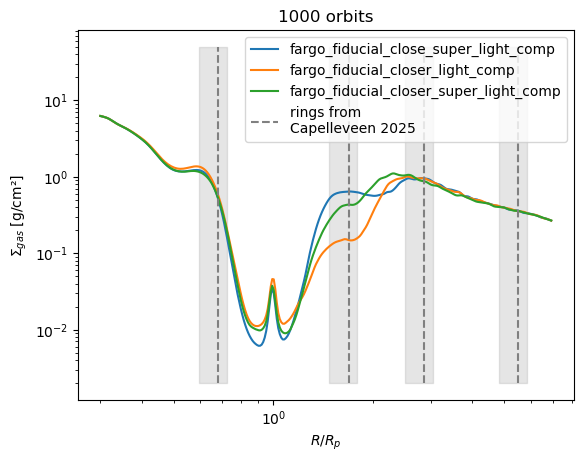

In [33]:


rho_mean = np.mean(rho_cube, axis=3)
for i in index_best_candidates:
    path = paths[i]
    plt.plot(r_list,rho_mean[i][-1], label=f"{path[43:-5]}")

r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper



first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[2e-3,5e1], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 2e-3,5e1, alpha=0.2, color="gray")
        

#plt.plot([gap,gap,],[1e-3,1e1], color="gray",label="gap from \nCapelleveen 2025")
#plt.fill_between([gap-gap_width,gap+gap_width], 1e-3,1e1, alpha=0.2)

plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma_{gas}$ [g/cm²]")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_feelings_densities.png")


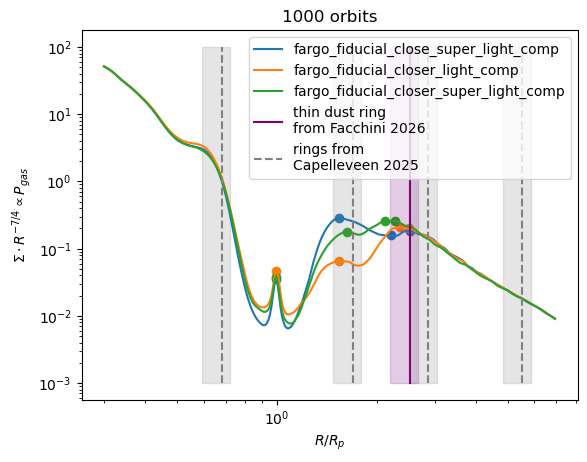

In [34]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_best_candidates:
    path = paths[i]
    press = rho_mean[i][-1]*np.power(r_list,-7/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,press, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], press[local_max])

first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{-7/4} \\propto P_{gas} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper right")
plt.savefig("radmc3d_sims/img/companion_close_dust_traps.png")

## Scattering Surface?

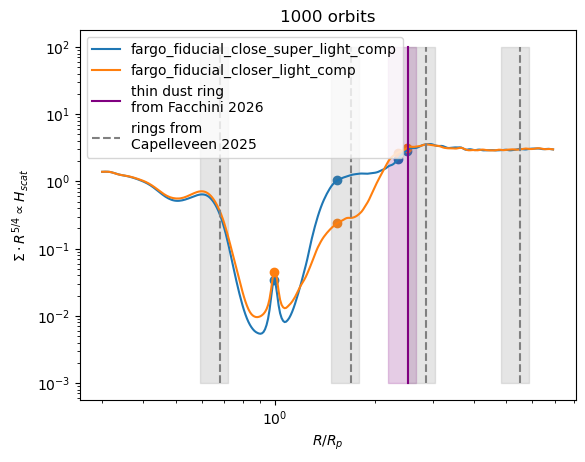

In [34]:
from scipy.signal import argrelextrema

# for local maxima

rho_mean = np.mean(rho_cube, axis=3)

for i in index_best_candidates:
    path = paths[i]
    hscat = rho_mean[i][-1]*np.power(r_list,5/4)
    local_max = argrelextrema(press, np.greater)
    plt.plot(r_list,hscat, label=f"{path[43:-5]}")

    ## dots are local extrema
    plt.scatter(r_list[local_max], hscat[local_max])



first=True
r_p = 57.3
r_p_upper = r_p+8.3
r_p_lower = r_p-3.3
rings_from_capelleveen = np.array([316, 164, 97, 39])/r_p # in r/r_p
rings_lower = np.array([316, 164, 97, 39])/r_p_lower
rings_upper = np.array([316, 164, 97, 39])/r_p_upper

dust_ring = 144.4/r_p
dust_ring_upper = 144.4/r_p_upper
dust_ring_lower = 144.4/r_p_lower

plt.plot([dust_ring , dust_ring],[1e-3,1e2], label="thin dust ring \nfrom Facchini 2026",color="purple")
plt.fill_between([dust_ring_lower, dust_ring_upper], 1e-3,1e2, alpha=0.2, color="purple")

first=True
for it,r in enumerate(rings_from_capelleveen):
    if first:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed", label="rings from \nCapelleveen 2025")
        first=False
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
    else:
        plt.plot([r,r,],[1e-3,1e2], color="gray", linestyle="dashed")
        plt.fill_between([rings_lower[it], rings_upper[it]], 1e-3,1e2, alpha=0.2, color="gray")
        
plt.xlabel("$R/R_p$")
plt.ylabel("$\\Sigma \\cdot R^{5/4} \\propto H_{scat} $")
plt.xscale("log")
plt.yscale("log")
plt.title(f"{frames[-1]*10} orbits")
plt.legend(loc="upper left")
plt.savefig("radmc3d_sims/img/companion_close_dust_traps.png")